In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier


# ============================================
# PROJECT ROOT
# ============================================

ROOT = Path(
    r"D:\My_Project\Analyse\capston Project_2-Global Supply Chain Risk & Logistics"
)


# ============================================
# PATHS
# ============================================

PROCESSED_PATH = (
    ROOT
    / "data"
    / "processed"
)

MODEL_PATH = (
    ROOT
    / "models"
)

REPORT_PATH = (
    ROOT
    / "reports"
)


# ============================================
# CREATE FOLDERS
# ============================================

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_PATH.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================
# LOAD TRAINING DATA
# ============================================

train = pd.read_csv(
    PROCESSED_PATH / "train.csv"
)


# ============================================
# LOAD VALIDATION DATA
# ============================================

validation = pd.read_csv(
    PROCESSED_PATH / "validation.csv"
)


# ============================================
# SEPARATE FEATURES AND TARGET
# ============================================

X_train = train.drop(
    columns=["disruption"]
)

y_train = train["disruption"].astype(int)


X_validation = validation.drop(
    columns=["disruption"]
)

y_validation = validation["disruption"].astype(int)


# ============================================
# CHECK DATA
# ============================================

print("Training shape:")
print(X_train.shape)

print("\nValidation shape:")
print(X_validation.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nValidation target:")
print(y_validation.value_counts())

Training shape:
(3000, 12)

Validation shape:
(1000, 12)

Training target:
disruption
1    1838
0    1162
Name: count, dtype: int64

Validation target:
disruption
1    613
0    387
Name: count, dtype: int64


In [2]:
# ============================================
# IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ============================================

numeric_columns = (
    X_train
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_columns = (
    X_train
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['distance_km', 'weight_mt', 'fuel_price_index', 'geopolitical_risk_score', 'carrier_reliability_score', 'lead_time_days']

Categorical columns:
['date', 'origin_port', 'destination_port', 'transport_mode', 'product_category', 'weather_condition']


In [3]:
# ============================================
# NUMERICAL PIPELINE
# ============================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ============================================
# CATEGORICAL PIPELINE
# ============================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ============================================
# PREPROCESSOR
# ============================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_columns
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns
        )
    ]
)


print("Preprocessor created successfully.")

Preprocessor created successfully.


In [4]:
random_forest = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            random_forest
        )
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

rf_prediction = rf_pipeline.predict(
    X_validation
)

rf_probability = (
    rf_pipeline
    .predict_proba(X_validation)[:, 1]
)

rf_metrics = {
    "Model": "Random Forest",

    "Accuracy": accuracy_score(
        y_validation,
        rf_prediction
    ),

    "Precision": precision_score(
        y_validation,
        rf_prediction,
        zero_division=0
    ),

    "Recall": recall_score(
        y_validation,
        rf_prediction,
        zero_division=0
    ),

    "F1": f1_score(
        y_validation,
        rf_prediction,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_validation,
        rf_probability
    )
}

print(rf_metrics)

{'Model': 'Random Forest', 'Accuracy': 0.727, 'Precision': 0.8256704980842912, 'Recall': 0.7030995106035889, 'F1': 0.7594713656387665, 'ROC_AUC': 0.8146195058824521}


In [5]:
joblib.dump(
    rf_pipeline,
    MODEL_PATH / "random_forest_model.pkl"
)

print(
    "Random Forest model saved."
)

Random Forest model saved.


In [6]:
xgboost = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            xgboost
        )
    ]
)

xgb_pipeline.fit(
    X_train,
    y_train
)

xgb_prediction = xgb_pipeline.predict(
    X_validation
)

xgb_probability = (
    xgb_pipeline
    .predict_proba(X_validation)[:, 1]
)

xgb_metrics = {
    "Model": "XGBoost",

    "Accuracy": accuracy_score(
        y_validation,
        xgb_prediction
    ),

    "Precision": precision_score(
        y_validation,
        xgb_prediction,
        zero_division=0
    ),

    "Recall": recall_score(
        y_validation,
        xgb_prediction,
        zero_division=0
    ),

    "F1": f1_score(
        y_validation,
        xgb_prediction,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_validation,
        xgb_probability
    )
}

print(xgb_metrics)

{'Model': 'XGBoost', 'Accuracy': 0.716, 'Precision': 0.767479674796748, 'Recall': 0.7699836867862969, 'F1': 0.7687296416938111, 'ROC_AUC': 0.8024457174652555}


In [7]:
joblib.dump(
    xgb_pipeline,
    MODEL_PATH / "xgboost_model.pkl"
)

print(
    "XGBoost model saved."
)

XGBoost model saved.


In [8]:
comparison = pd.DataFrame(
    [
        rf_metrics,
        xgb_metrics
    ]
)

comparison = comparison.sort_values(
    by=[
        "F1",
        "ROC_AUC",
        "Recall"
    ],
    ascending=False
)

comparison = comparison.reset_index(
    drop=True
)

display(comparison)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,0.716,0.76748,0.769984,0.768730,0.802446
1,Random Forest,0.727,0.82567,0.703100,0.759471,0.814620


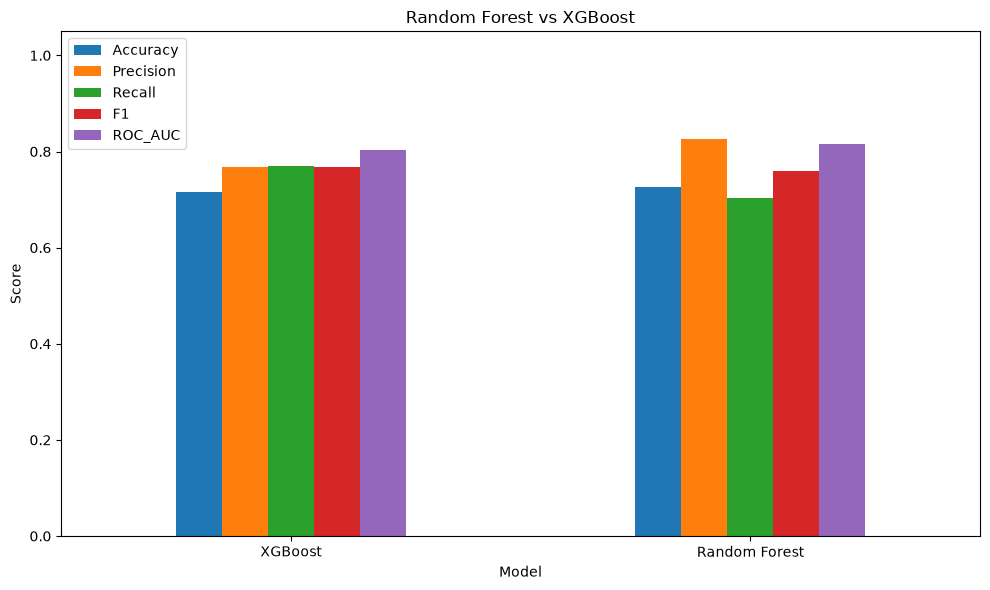

In [9]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

comparison.set_index(
    "Model"
)[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylim(0, 1.05)

plt.title(
    "Random Forest vs XGBoost"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    REPORT_PATH / "model_comparison.png",
    dpi=200
)

plt.show()

In [10]:
REPORT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

comparison.to_csv(
    REPORT_PATH / "model_comparison.csv",
    index=False
)

print(
    "Model comparison saved to:"
)

print(
    (REPORT_PATH / "model_comparison.csv").resolve()
)

best_model_name = comparison.iloc[0]["Model"]

print(
    "\nBest model:",
    best_model_name
)

Model comparison saved to:
D:\My_Project\Analyse\capston Project_2-Global Supply Chain Risk & Logistics\reports\model_comparison.csv

Best model: XGBoost
